# Анализ сделок trade-by-trade (последние 7 дней)

Подробный разбор каждой сделки бота:
- Сопоставление trade с decision_id из decisions.db
- Расчёт реализованного P&L по тикерам
- Win-rate и средняя длительность позиций
- Топ-3 «кровоточащих» тикеров и проблемные детекторы

**Цель:** найти где теряем деньги и какие detector/source портят статистику.

In [1]:
from __future__ import annotations
import json
import sqlite3
import urllib.request
import urllib.parse
from datetime import datetime, timedelta, timezone
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 200)

ROOT = Path('/Users/smokkkkiiii/Documents/MoexML/release_moex_ml').resolve()
DATA = ROOT / 'data'
TRADES_DB = DATA / 'trades.db'
DECISIONS_DB = DATA / 'decisions.db'
RECOVERY_PATH = DATA / 'recovery_state.json'

TEAM = '404: Loss Not Found'
API_TOKEN = '3cda1cc0bf1de51ad5e3e2a7b68baf8a4ee5295eae3c4154d382d9d58501ca19'
API_BASE = 'https://arenago.ru/api'
ISS_BASE = 'https://iss.moex.com/iss/engines/stock/markets/shares/securities'

TODAY = datetime.utcnow().date()
WINDOW_START = TODAY - timedelta(days=7)
print('today (UTC):', TODAY, '| 7-day window from', WINDOW_START)

today (UTC): 2026-05-27 | 7-day window from 2026-05-20


## 0 — Load data

Local `trades.db` is the schema mirror; the actual fills live on ArenaGo. We pull both and use ArenaGo as the source of truth, joining on `decision_id` only when the local mirror has the rows. We pull all decisions (also limited horizon).

In [2]:
import time, ssl
_SSL_CTX = ssl.create_default_context()

def http_get_json(url: str, headers: dict | None = None, timeout: float = 10.0, retries: int = 4):
    last_err = None
    for attempt in range(retries):
        try:
            req = urllib.request.Request(url, headers=headers or {})
            with urllib.request.urlopen(req, timeout=timeout, context=_SSL_CTX) as resp:
                return json.loads(resp.read())
        except Exception as e:
            last_err = e
            time.sleep(0.6 * (attempt + 1))
    raise last_err

AUTH = {'Authorization': API_TOKEN}

def fetch_live_trades():
    url = f"{API_BASE}/trades/{urllib.parse.quote(TEAM)}"
    return http_get_json(url, AUTH)

def fetch_live_positions():
    url = f"{API_BASE}/positions/{urllib.parse.quote(TEAM)}"
    return http_get_json(url, AUTH)

live_trades_raw = fetch_live_trades()
live_positions_raw = fetch_live_positions()
print('live trades:', len(live_trades_raw), '| live positions:', len(live_positions_raw))

live trades: 15 | live positions: 16


In [3]:
trades = pd.DataFrame(live_trades_raw)
if not trades.empty:
    trades['direction_full'] = trades['direction'].map({'B': 'BUY', 'S': 'SELL'})
    trades['ts'] = pd.to_datetime(trades['tradedate'] + ' ' + trades['tradetime'], utc=False, errors='coerce')
    trades['signed_qty'] = np.where(trades['direction'] == 'B', trades['quantity'], -trades['quantity'])
    trades['notional'] = trades['price'] * trades['quantity']
    trades = trades.sort_values('ts').reset_index(drop=True)
trades.head()

,bot,direction,id,nickname,price,quantity,secid,tradedate,tradetime,direction_full,ts,signed_qty,notional
0,404: Loss Not Found,S,73529,red.pen.5a.mi,115.69,11,GAZP,2026-05-27,04:02:43.304128,SELL,2026-05-27 04:02:43.304128,-11,1272.59
1,404: Loss Not Found,S,73562,red.pen.5a.mi,115.42,10,GAZP,2026-05-27,04:12:59.073135,SELL,2026-05-27 04:12:59.073135,-10,1154.20
2,404: Loss Not Found,S,73650,red.pen.5a.mi,115.53,10,GAZP,2026-05-27,04:32:52.227615,SELL,2026-05-27 04:32:52.227615,-10,1155.30
3,404: Loss Not Found,S,73663,red.pen.5a.mi,115.59,9,GAZP,2026-05-27,04:41:42.564116,SELL,2026-05-27 04:41:42.564116,-9,1040.31
4,404: Loss Not Found,B,74539,red.pen.5a.mi,320.32,36,SBER,2026-05-27,08:17:19.345770,BUY,2026-05-27 08:17:19.345770,36,11531.52


In [4]:
positions = pd.DataFrame(live_positions_raw)
if not positions.empty:
    positions['direction_full'] = positions['direction'].map({'B': 'LONG', 'S': 'SHORT'})
positions

,average_price,bot,direction,id,nickname,position,secid,updatedate,updatetime,direction_full
0,703.910000,404: Loss Not Found,S,17362,red.pen.5a.mi,-5,CHMF,2026-05-27,09:41:46.671534,SHORT
1,320.520574,404: Loss Not Found,B,17255,red.pen.5a.mi,288,SBER,2026-05-27,08:39:59.166013,LONG
2,115.965545,404: Loss Not Found,S,17329,red.pen.5a.mi,-110,GAZP,2026-05-27,04:41:42.467292,SHORT
3,228.338462,404: Loss Not Found,S,17372,red.pen.5a.mi,-13,MTSS,2026-05-26,15:35:48.372717,SHORT
4,173.897143,404: Loss Not Found,S,17363,red.pen.5a.mi,-21,MOEX,2026-05-26,15:35:46.108369,SHORT
5,81.370051,404: Loss Not Found,S,17308,red.pen.5a.mi,-197,NLMK,2026-05-26,15:35:45.087840,SHORT
6,48.390000,404: Loss Not Found,S,17259,red.pen.5a.mi,-351,AFLT,2026-05-26,15:35:42.747050,SHORT
7,127.056364,404: Loss Not Found,S,17306,red.pen.5a.mi,-99,GMKN,2026-05-26,15:35:41.929726,SHORT
8,302.460909,404: Loss Not Found,S,17330,red.pen.5a.mi,-22,T,2026-05-26,15:35:40.234752,SHORT
9,389.421711,404: Loss Not Found,S,17256,red.pen.5a.mi,-152,ROSN,2026-05-26,15:35:35.414544,SHORT


In [5]:
def read_sql(path: Path, sql: str) -> pd.DataFrame:
    if not path.exists():
        return pd.DataFrame()
    con = sqlite3.connect(str(path))
    try:
        return pd.read_sql_query(sql, con)
    finally:
        con.close()

trades_local = read_sql(TRADES_DB, 'SELECT * FROM trades ORDER BY trade_date, trade_time')
decisions = read_sql(DECISIONS_DB, 'SELECT * FROM decisions ORDER BY created_at')
print('local trades.db rows:', len(trades_local), '| decisions.db rows:', len(decisions))

local trades.db rows: 0 | decisions.db rows: 30


In [6]:
def parse_signals(s):
    try:
        return json.loads(s) if s else []
    except Exception:
        return []

if not decisions.empty:
    decisions['created_at_dt'] = pd.to_datetime(decisions['created_at'], errors='coerce', utc=True)
    decisions['executed_at_dt'] = pd.to_datetime(decisions['executed_at'], errors='coerce', utc=True)
    decisions['signals'] = decisions['signals_json'].apply(parse_signals)
    decisions['detectors'] = decisions['signals'].apply(lambda lst: [s.get('detector') for s in lst if isinstance(s, dict)])
    decisions['sources'] = decisions['signals'].apply(lambda lst: sorted({s.get('source') for s in lst if isinstance(s, dict)}))
    decisions['detector_primary'] = decisions['detectors'].apply(lambda d: d[0] if d else None)
    decisions['source_primary'] = decisions['sources'].apply(lambda s: s[0] if s else None)
    decisions['expected_rr'] = decisions['signals'].apply(lambda lst: (lst[0].get('expected_rr') if lst else None))
    decisions['signal_price'] = decisions['signals'].apply(lambda lst: (lst[0].get('price') if lst else None))
decisions[['decision_id','ticker','action','direction','tier','source_primary','detector_primary','expected_rr','stop_loss','take_profit','executed_bool','pnl_rub']].head()

,decision_id,ticker,action,direction,tier,source_primary,detector_primary,expected_rr,stop_loss,take_profit,executed_bool,pnl_rub
0,0a5cd219967158c1,SBER,EXECUTE,BUY,3,TA,bull_flag,1.0,292.0,299.5,0,None
1,c0a2f91f8e6e35e2,SBER,EXECUTE,BUY,3,TA,bull_flag,1.0,292.0,299.5,0,None
2,6e0cf4098e1b818a,SBER,EXECUTE,BUY,3,TA,bull_flag,1.0,292.0,299.5,0,None
3,0d8cdb8ae243abff,SBER,EXECUTE,BUY,3,TA,bull_flag,1.0,292.0,299.5,0,None
4,5820175370fb5fcf,SBER,EXECUTE,BUY,3,TA,bull_flag,1.0,292.0,299.5,0,None


## 1 — Trade-by-trade walk-through (last 7 days)

We pair every executed trade with its originating decision (best-effort: by ticker + direction + nearest timestamp, since `trades.db` is empty and ArenaGo does not return `decision_id`).

For each ticker, we then walk fills chronologically, FIFO-net the qty, and compute realized PnL per closed leg.

In [7]:
def match_decision(row, decisions_df):
    """Best-effort: match by ticker + direction (B->BUY, S->SELL) + nearest decision created_at <= trade ts."""
    if decisions_df.empty:
        return None
    want_dir = 'BUY' if row['direction'] == 'B' else 'SELL'
    cand = decisions_df[(decisions_df['ticker'] == row['secid']) & (decisions_df['direction'] == want_dir)]
    if cand.empty:
        return None
    ts = pd.Timestamp(row['ts']).tz_localize('Europe/Moscow', nonexistent='shift_forward', ambiguous='NaT').tz_convert('UTC')
    delta = (cand['created_at_dt'] - ts).abs()
    best_idx = delta.idxmin()
    return cand.loc[best_idx, 'decision_id']

if not trades.empty and not decisions.empty:
    trades['decision_id_match'] = trades.apply(lambda r: match_decision(r, decisions), axis=1)
    trades = trades.merge(
        decisions[['decision_id', 'tier', 'detector_primary', 'source_primary', 'rationale', 'stop_loss', 'take_profit', 'expected_rr']],
        how='left', left_on='decision_id_match', right_on='decision_id'
    )
trades.head()

,bot,direction,id,nickname,price,quantity,secid,tradedate,tradetime,direction_full,ts,signed_qty,notional,decision_id_match,decision_id,tier,detector_primary,source_primary,rationale,stop_loss,take_profit,expected_rr
0,404: Loss Not Found,S,73529,red.pen.5a.mi,115.69,11,GAZP,2026-05-27,04:02:43.304128,SELL,2026-05-27 04:02:43.304128,-11,1272.59,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,404: Loss Not Found,S,73562,red.pen.5a.mi,115.42,10,GAZP,2026-05-27,04:12:59.073135,SELL,2026-05-27 04:12:59.073135,-10,1154.20,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,404: Loss Not Found,S,73650,red.pen.5a.mi,115.53,10,GAZP,2026-05-27,04:32:52.227615,SELL,2026-05-27 04:32:52.227615,-10,1155.30,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,404: Loss Not Found,S,73663,red.pen.5a.mi,115.59,9,GAZP,2026-05-27,04:41:42.564116,SELL,2026-05-27 04:41:42.564116,-9,1040.31,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,404: Loss Not Found,B,74539,red.pen.5a.mi,320.32,36,SBER,2026-05-27,08:17:19.345770,BUY,2026-05-27 08:17:19.345770,36,11531.52,be5bc2de50af03fa,be5bc2de50af03fa,3,bull_flag,TA,STANDALONE BUY | sources=['TA'] | detectors=['...,292.0,299.5,1.0


In [8]:
from collections import deque

def fifo_pnl_clean(group: pd.DataFrame) -> pd.DataFrame:
    """Walk fills for ONE ticker chronologically. Maintain FIFO long & short queues.
    For each fill, close as much opposite-side inventory as possible and record realized PnL on those closes;
    any remainder opens a new lot in its own side."""
    long_q = deque()   # entries (qty>0, price)
    short_q = deque()  # entries (qty positive, price) but conceptually short
    rows = []
    for _, r in group.sort_values('ts').iterrows():
        side = r['direction']  # 'B' or 'S'
        qty = int(r['quantity'])
        price = float(r['price'])
        realized = 0.0
        remaining = qty
        if side == 'B':
            while remaining > 0 and short_q:
                sq, sp = short_q[0]
                take = min(remaining, sq)
                realized += (sp - price) * take
                if take == sq:
                    short_q.popleft()
                else:
                    short_q[0] = (sq - take, sp)
                remaining -= take
            if remaining > 0:
                long_q.append((remaining, price))
        else:  # 'S'
            while remaining > 0 and long_q:
                lq, lp = long_q[0]
                take = min(remaining, lq)
                realized += (price - lp) * take
                if take == lq:
                    long_q.popleft()
                else:
                    long_q[0] = (lq - take, lp)
                remaining -= take
            if remaining > 0:
                short_q.append((remaining, price))
        net_long = sum(q for q, _ in long_q) - sum(q for q, _ in short_q)
        rows.append({
            'ts': r['ts'], 'secid': r['secid'], 'direction': r['direction'],
            'qty': qty, 'price': price, 'notional': r['notional'],
            'realized_pnl_rub': realized,
            'net_position_after': net_long,
            'detector': r.get('detector_primary'),
            'source': r.get('source_primary'),
            'tier': r.get('tier')
        })
    return pd.DataFrame(rows)

if trades.empty:
    walk = pd.DataFrame()
else:
    walk = pd.concat([fifo_pnl_clean(g) for _, g in trades.groupby('secid')], ignore_index=True).sort_values('ts').reset_index(drop=True)
walk

,ts,secid,direction,qty,price,notional,realized_pnl_rub,net_position_after,detector,source,tier
0,2026-05-27 04:02:43.304128,GAZP,S,11,115.690,1272.590,0.0,-11,NaN,NaN,NaN
1,2026-05-27 04:12:59.073135,GAZP,S,10,115.420,1154.200,0.0,-21,NaN,NaN,NaN
2,2026-05-27 04:32:52.227615,GAZP,S,10,115.530,1155.300,0.0,-31,NaN,NaN,NaN
3,2026-05-27 04:41:42.564116,GAZP,S,9,115.590,1040.310,0.0,-40,NaN,NaN,NaN
4,2026-05-27 08:17:19.345770,SBER,B,36,320.320,11531.520,0.0,36,bull_flag,TA,3
5,2026-05-27 08:19:42.020113,SBER,B,72,320.190,23053.680,0.0,108,bull_flag,TA,3
6,2026-05-27 08:39:55.815862,CHMF,B,1,705.600,705.600,0.0,1,NaN,NaN,NaN
7,2026-05-27 08:39:59.275472,SBER,B,144,320.620,46169.280,0.0,252,bull_flag,TA,3
8,2026-05-27 08:54:58.237996,VTBR,B,185,79.095,14632.575,0.0,185,NaN,NaN,NaN
9,2026-05-27 08:55:17.268866,VTBR,B,185,79.200,14652.000,0.0,370,NaN,NaN,NaN


In [9]:
if not walk.empty:
    closed_trades = walk[walk['realized_pnl_rub'] != 0.0].copy()
    closed_trades['win'] = closed_trades['realized_pnl_rub'] > 0
    print(f"realized PnL events: {len(closed_trades)} | total RUB: {closed_trades['realized_pnl_rub'].sum():.0f} | win rate: {closed_trades['win'].mean()*100:.1f}%")
    display(closed_trades[['ts','secid','direction','qty','price','realized_pnl_rub','detector','source','tier']])
else:
    closed_trades = pd.DataFrame()
    print('No trades to analyze yet.')

realized PnL events: 2 | total RUB: 306 | win rate: 50.0%


,ts,secid,direction,qty,price,realized_pnl_rub,detector,source,tier
12,2026-05-27 09:41:44.442030,CHMF,S,1,704.600,-1.0,NaN,NaN,NaN
14,2026-05-27 09:42:20.620600,VTBR,S,740,79.695,307.1,NaN,NaN,NaN


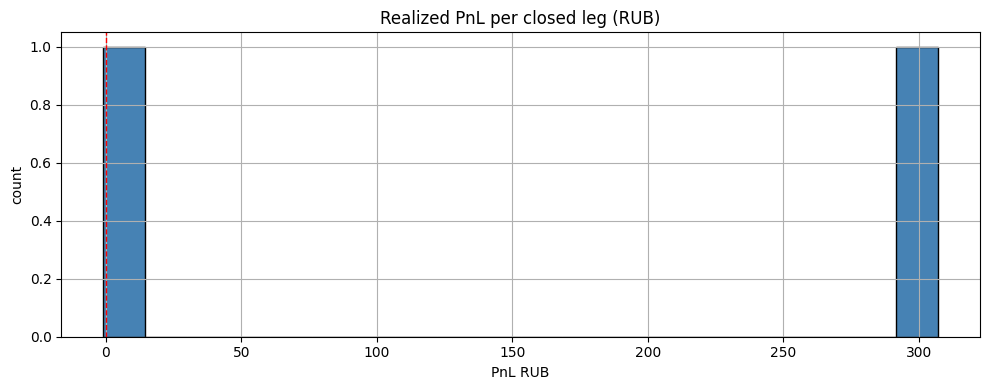

No detector PnL aggregation possible (no closed legs had a detector label).


In [10]:
if not closed_trades.empty:
    fig, ax = plt.subplots(figsize=(10, 4))
    closed_trades['realized_pnl_rub'].hist(bins=20, ax=ax, color='steelblue', edgecolor='black')
    ax.axvline(0, color='red', linestyle='--', linewidth=1)
    ax.set_title('Realized PnL per closed leg (RUB)')
    ax.set_xlabel('PnL RUB'); ax.set_ylabel('count')
    plt.tight_layout(); plt.show()

    pnl_by_det = closed_trades.groupby('detector')['realized_pnl_rub'].sum().sort_values()
    if len(pnl_by_det) > 0:
        fig, ax = plt.subplots(figsize=(10, 4))
        colors = ['crimson' if v < 0 else 'seagreen' for v in pnl_by_det.values]
        pnl_by_det.plot(kind='barh', ax=ax, color=colors)
        ax.set_title('Realized PnL by detector (RUB)')
        ax.axvline(0, color='black', linewidth=0.5)
        plt.tight_layout(); plt.show()
    else:
        print('No detector PnL aggregation possible (no closed legs had a detector label).')
else:
    print('No closed legs to plot — all open positions still alive (no realized PnL yet today).')

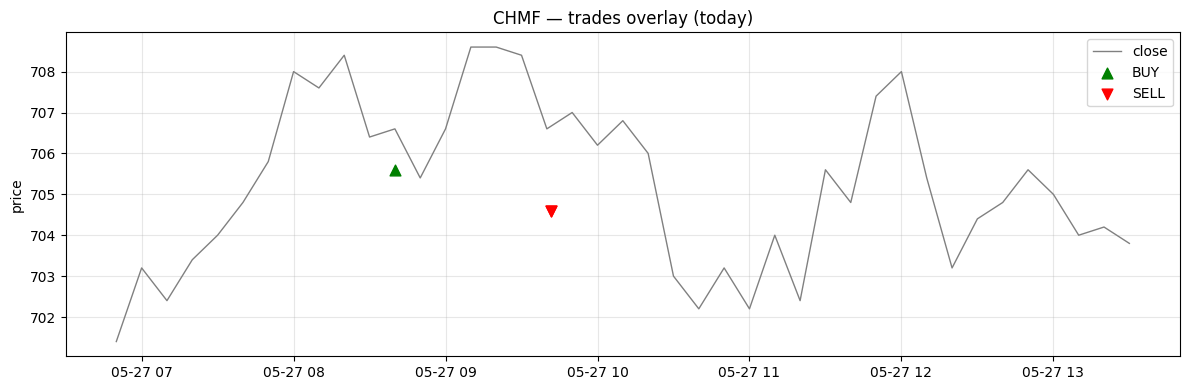

,ts,direction,quantity,price,detector_primary,source_primary,tier
6,2026-05-27 08:39:55.815862,B,1,705.6,NaN,NaN,NaN
12,2026-05-27 09:41:44.442030,S,1,704.6,NaN,NaN,NaN
13,2026-05-27 09:41:46.768719,S,1,704.6,NaN,NaN,NaN


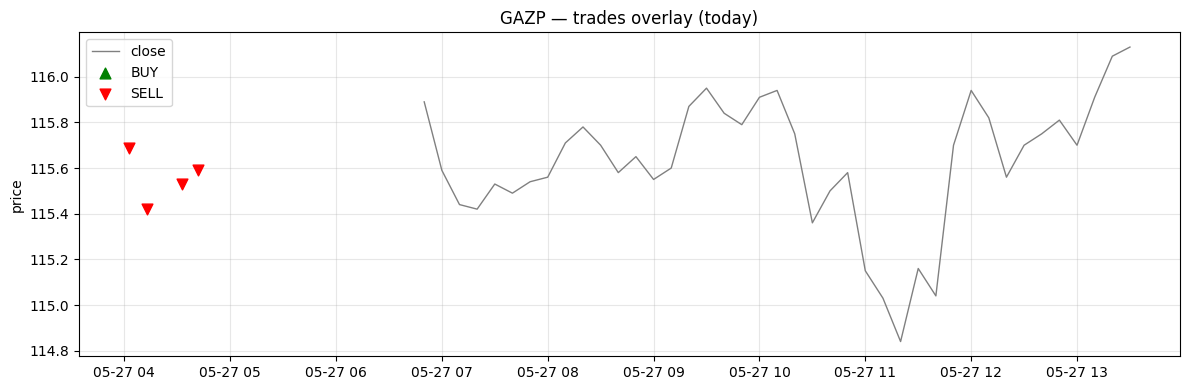

,ts,direction,quantity,price,detector_primary,source_primary,tier
0,2026-05-27 04:02:43.304128,S,11,115.69,NaN,NaN,NaN
1,2026-05-27 04:12:59.073135,S,10,115.42,NaN,NaN,NaN
2,2026-05-27 04:32:52.227615,S,10,115.53,NaN,NaN,NaN
3,2026-05-27 04:41:42.564116,S,9,115.59,NaN,NaN,NaN


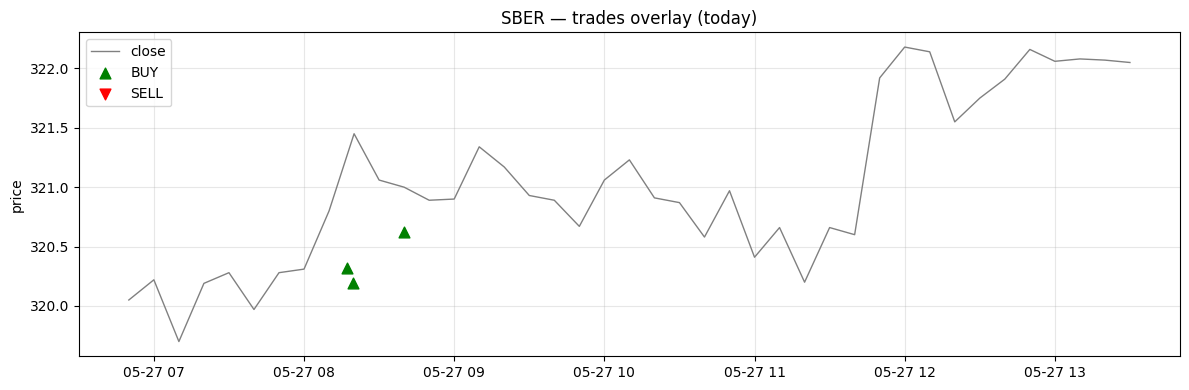

,ts,direction,quantity,price,detector_primary,source_primary,tier
4,2026-05-27 08:17:19.345770,B,36,320.32,bull_flag,TA,3
5,2026-05-27 08:19:42.020113,B,72,320.19,bull_flag,TA,3
7,2026-05-27 08:39:59.275472,B,144,320.62,bull_flag,TA,3


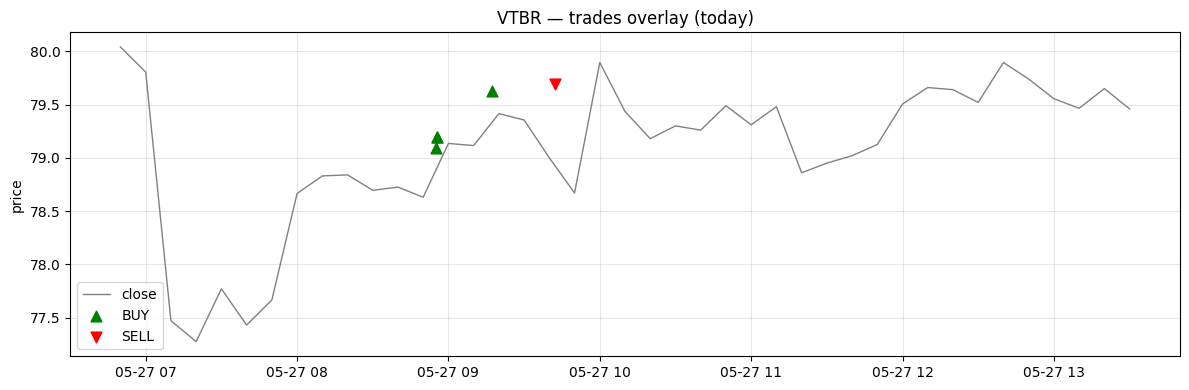

,ts,direction,quantity,price,detector_primary,source_primary,tier
8,2026-05-27 08:54:58.237996,B,185,79.095,NaN,NaN,NaN
9,2026-05-27 08:55:17.268866,B,185,79.200,NaN,NaN,NaN
10,2026-05-27 08:55:21.345518,B,185,79.200,NaN,NaN,NaN
11,2026-05-27 09:17:05.169097,B,370,79.625,NaN,NaN,NaN
14,2026-05-27 09:42:20.620600,S,740,79.695,NaN,NaN,NaN


In [11]:
import time

def fetch_candles(ticker: str, from_date: str, till_date: str, interval: int = 10, retries: int = 3):
    url = f"{ISS_BASE}/{ticker}/candles.json?from={from_date}&till={till_date}&interval={interval}"
    for attempt in range(retries):
        try:
            d = http_get_json(url, timeout=10)
            cols = d['candles']['columns']
            df = pd.DataFrame(d['candles']['data'], columns=cols)
            df['begin'] = pd.to_datetime(df['begin'])
            return df
        except Exception as e:
            if attempt == retries - 1:
                print(f'candles fetch failed for {ticker}: {e}')
                return pd.DataFrame()
            time.sleep(0.7 * (attempt + 1))
    return pd.DataFrame()

def plot_ticker_overlay(ticker, ticker_trades, candles):
    if candles.empty:
        print(f'no candles for {ticker}')
        return
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(candles['begin'], candles['close'], color='gray', linewidth=1, label='close')
    buys = ticker_trades[ticker_trades['direction'] == 'B']
    sells = ticker_trades[ticker_trades['direction'] == 'S']
    ax.scatter(buys['ts'], buys['price'], color='green', s=60, marker='^', label='BUY', zorder=3)
    ax.scatter(sells['ts'], sells['price'], color='red', s=60, marker='v', label='SELL', zorder=3)
    ax.set_title(f'{ticker} — trades overlay (today)')
    ax.set_ylabel('price')
    ax.legend(loc='best'); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

if not trades.empty:
    for ticker, grp in trades.groupby('secid'):
        date_str = str(TODAY)
        candles = fetch_candles(ticker, date_str, date_str, interval=10)
        plot_ticker_overlay(ticker, grp, candles)
        display(grp[['ts','direction','quantity','price','detector_primary','source_primary','tier']])

## 2 — Per-ticker stats

Realized PnL (FIFO), win rate, average holding, best/worst detector per ticker, plus current open position with unrealized PnL marked against the last available 10-min close.

In [12]:
def fetch_last_price(ticker: str):
    """Try today's candles, then yesterday, then 7d window."""
    for from_d, till_d in [(TODAY, TODAY), (TODAY - timedelta(days=1), TODAY), (TODAY - timedelta(days=7), TODAY)]:
        df = fetch_candles(ticker, str(from_d), str(till_d), interval=10)
        if not df.empty:
            return float(df['close'].iloc[-1]), df
    return None, pd.DataFrame()

last_prices = {}
for t in positions['secid'].unique() if not positions.empty else []:
    last_prices[t], _ = fetch_last_price(t)
print({k: v for k, v in last_prices.items() if v is not None})

{'CHMF': 703.8, 'SBER': 322.05, 'GAZP': 116.13, 'MTSS': 230.45, 'MOEX': 174.87, 'NLMK': 81.1, 'AFLT': 48.17, 'GMKN': 126.82, 'T': 302.74, 'ROSN': 391.1, 'SNGSP': 40.73, 'ALRS': 26.33, 'NVTK': 1065.0, 'PIKK': 541.2, 'X5': 2451.0, 'PLZL': 2118.4}


In [13]:
def per_ticker_stats(trades_df, walk_df, positions_df):
    rows = []
    tickers = sorted(set(list(trades_df['secid'].unique()) + list(positions_df['secid'].unique() if not positions_df.empty else [])))
    for t in tickers:
        t_trades = trades_df[trades_df['secid'] == t] if not trades_df.empty else pd.DataFrame()
        t_walk = walk_df[walk_df['secid'] == t] if not walk_df.empty else pd.DataFrame()
        closed = t_walk[t_walk['realized_pnl_rub'] != 0.0]
        n_trades = len(t_trades)
        realized = closed['realized_pnl_rub'].sum() if not closed.empty else 0.0
        wr = (closed['realized_pnl_rub'] > 0).mean() * 100 if not closed.empty else np.nan
        avg_hold = np.nan
        if not closed.empty and len(t_trades) >= 2:
            durations = []
            tt = t_trades.sort_values('ts').reset_index(drop=True)
            for i in range(1, len(tt)):
                if tt.loc[i, 'direction'] != tt.loc[i-1, 'direction']:
                    durations.append((tt.loc[i, 'ts'] - tt.loc[i-1, 'ts']).total_seconds() / 60)
            if durations:
                avg_hold = float(np.mean(durations))
        biggest_loss = closed['realized_pnl_rub'].min() if not closed.empty else 0.0
        biggest_win = closed['realized_pnl_rub'].max() if not closed.empty else 0.0

        det_wr = {}
        if not closed.empty and 'detector' in closed.columns:
            for det, sub in closed.groupby('detector'):
                if det is None: continue
                det_wr[det] = ((sub['realized_pnl_rub'] > 0).mean(), sub['realized_pnl_rub'].sum())
        best_det = max(det_wr.items(), key=lambda kv: kv[1][1])[0] if det_wr else None
        worst_det = min(det_wr.items(), key=lambda kv: kv[1][1])[0] if det_wr else None

        open_row = positions_df[positions_df['secid'] == t]
        if not open_row.empty:
            pos = open_row.iloc[0]
            cur_p = last_prices.get(t)
            upnl = None
            if cur_p is not None:
                if pos['position'] > 0:
                    upnl = (cur_p - pos['average_price']) * pos['position']
                else:
                    upnl = (pos['average_price'] - cur_p) * abs(pos['position'])
            open_str = f"{pos['direction_full']} {pos['position']} @ {pos['average_price']:.3f}"
        else:
            open_str = ''
            upnl = None

        rows.append({
            'ticker': t,
            'n_trades_7d': n_trades,
            'realized_pnl_rub': round(realized, 1),
            'win_rate_pct': round(wr, 1) if not np.isnan(wr) else None,
            'avg_holding_min': round(avg_hold, 1) if not np.isnan(avg_hold) else None,
            'biggest_loss': round(biggest_loss, 1),
            'biggest_win': round(biggest_win, 1),
            'open_position': open_str,
            'unrealized_pnl_rub': round(upnl, 1) if upnl is not None else None,
            'best_detector': best_det,
            'worst_detector': worst_det,
        })
    return pd.DataFrame(rows).sort_values('realized_pnl_rub')

stats = per_ticker_stats(trades, walk, positions)
stats

,ticker,n_trades_7d,realized_pnl_rub,win_rate_pct,avg_holding_min,biggest_loss,biggest_win,open_position,unrealized_pnl_rub,best_detector,worst_detector
2,CHMF,3,-1.0,0.0,61.8,-1.0,-1.0,SHORT -5 @ 703.910,0.6,None,None
0,AFLT,0,0.0,NaN,NaN,0.0,0.0,SHORT -351 @ 48.390,77.2,None,None
14,T,0,0.0,NaN,NaN,0.0,0.0,SHORT -22 @ 302.461,-6.1,None,None
13,SNGSP,0,0.0,NaN,NaN,0.0,0.0,SHORT -103 @ 40.600,-13.4,None,None
12,SBER,3,0.0,NaN,NaN,0.0,0.0,LONG 288 @ 320.521,440.5,None,None
11,ROSN,0,0.0,NaN,NaN,0.0,0.0,SHORT -152 @ 389.422,-255.1,None,None
10,PLZL,0,0.0,NaN,NaN,0.0,0.0,SHORT -5 @ 2119.280,4.4,None,None
9,PIKK,0,0.0,NaN,NaN,0.0,0.0,SHORT -72 @ 541.330,9.3,None,None
8,NVTK,0,0.0,NaN,NaN,0.0,0.0,SHORT -1 @ 1062.900,-2.1,None,None
7,NLMK,0,0.0,NaN,NaN,0.0,0.0,SHORT -197 @ 81.370,53.2,None,None


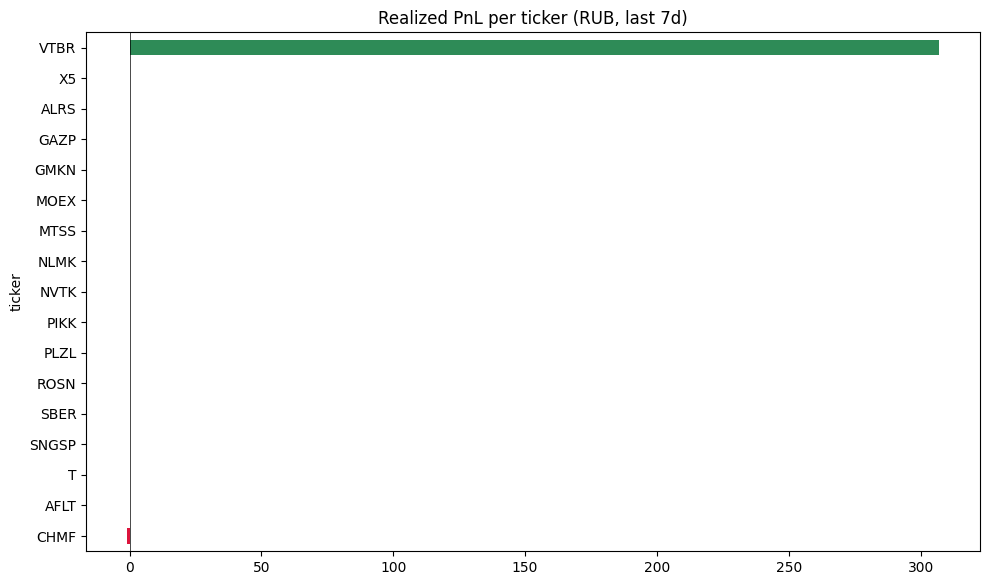

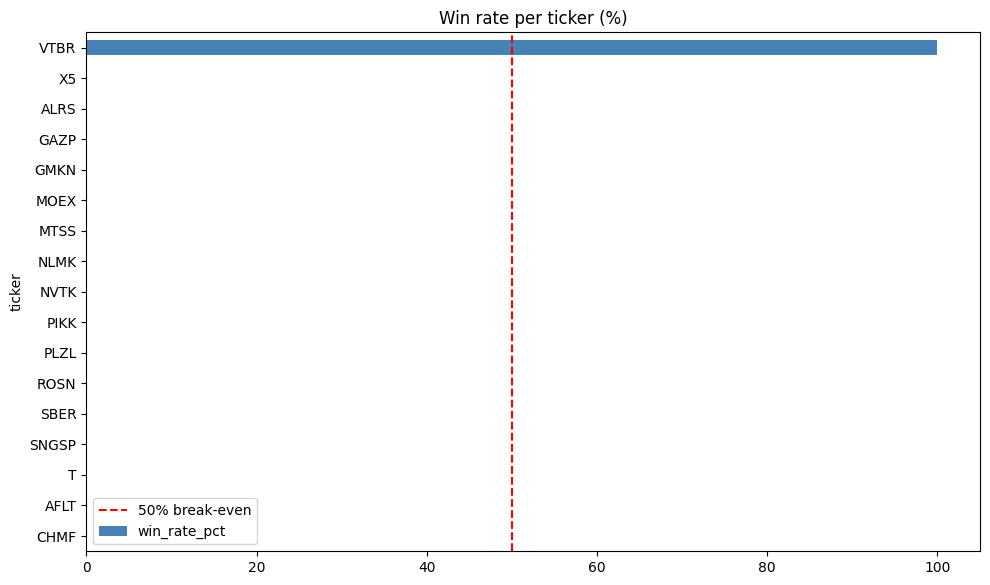

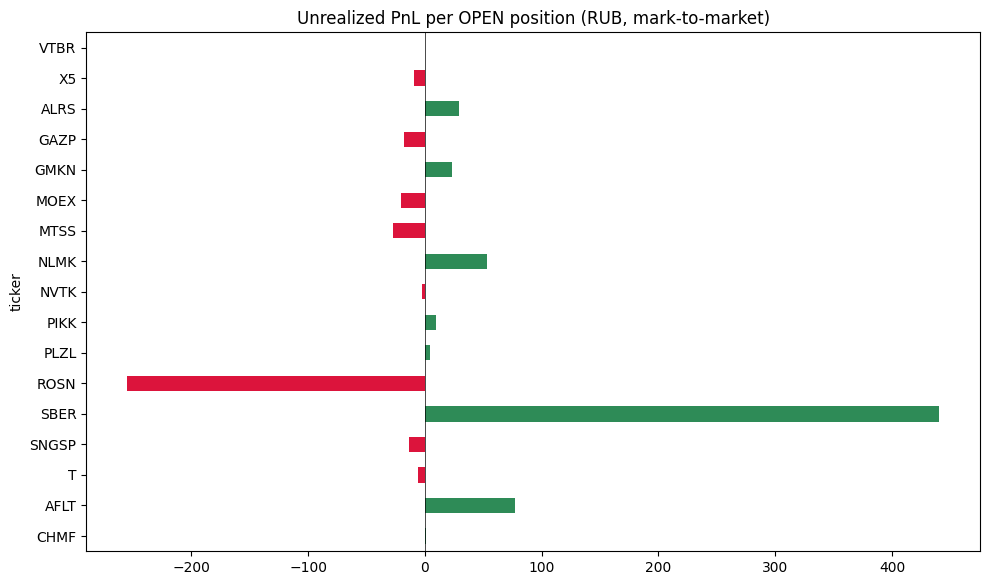

In [14]:
def safe_barh(series, title, color_rule='sign', flat_color='steelblue', extra_axvline=None, label=None):
    """Bar chart that tolerates empty / single-row / all-zero inputs."""
    if series is None or len(series) == 0:
        print(f'(skipped plot "{title}" — no data)')
        return
    s = series.copy()
    fig, ax = plt.subplots(figsize=(10, max(3, 0.35 * len(s))))
    if color_rule == 'sign':
        cols = ['crimson' if v < 0 else 'seagreen' for v in s.values]
    else:
        cols = flat_color
    s.plot(kind='barh', ax=ax, color=cols)
    ax.set_title(title)
    ax.axvline(0, color='black', linewidth=0.5)
    if extra_axvline is not None:
        ax.axvline(extra_axvline, color='red', linestyle='--', label=label)
        ax.legend()
    plt.tight_layout(); plt.show()

if not stats.empty:
    safe_barh(stats.set_index('ticker')['realized_pnl_rub'], 'Realized PnL per ticker (RUB, last 7d)')
    safe_barh(stats.set_index('ticker')['win_rate_pct'].fillna(0), 'Win rate per ticker (%)', color_rule='flat', extra_axvline=50, label='50% break-even')
    safe_barh(stats.set_index('ticker')['unrealized_pnl_rub'].fillna(0), 'Unrealized PnL per OPEN position (RUB, mark-to-market)')
else:
    print('Empty stats.')

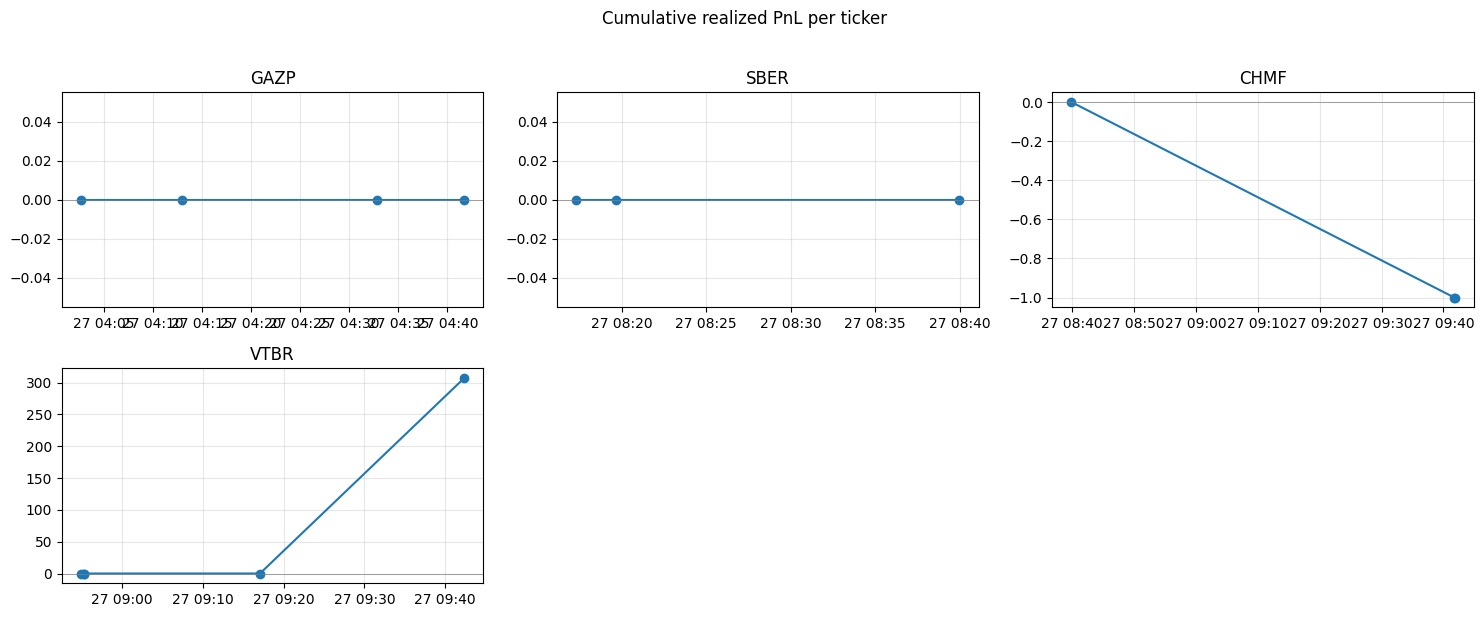

In [15]:
# Cumulative equity curve per ticker (small multiples)
if not walk.empty:
    tickers = walk['secid'].unique()
    n = len(tickers)
    cols = 3
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(15, 3 * rows), squeeze=False)
    for i, t in enumerate(tickers):
        ax = axes[i // cols][i % cols]
        sub = walk[walk['secid'] == t].sort_values('ts').copy()
        sub['cum_pnl'] = sub['realized_pnl_rub'].cumsum()
        ax.plot(sub['ts'], sub['cum_pnl'], marker='o', linewidth=1.5)
        ax.axhline(0, color='gray', linewidth=0.5)
        ax.set_title(t); ax.grid(alpha=0.3)
    for j in range(n, rows * cols):
        axes[j // cols][j % cols].axis('off')
    plt.suptitle('Cumulative realized PnL per ticker', y=1.02)
    plt.tight_layout(); plt.show()

## 3 — Critical findings

Quantitative checks: concentration, detector concentration, time-of-day, duplicate decisions.

In [16]:
# 3.1 — Concentration of capital per position (mark-to-market)
DEPOSIT_RUB = 1_000_000.0  # contest deposit
if not positions.empty:
    conc = positions.copy()
    conc['cur_price'] = conc['secid'].map(last_prices)
    conc['exposure_rub'] = conc['cur_price'].fillna(conc['average_price']) * conc['position'].abs()
    conc['exposure_pct_deposit'] = conc['exposure_rub'] / DEPOSIT_RUB * 100
    conc = conc[['secid','direction_full','position','average_price','cur_price','exposure_rub','exposure_pct_deposit']].sort_values('exposure_pct_deposit', ascending=False)
    print('Total gross exposure (RUB):', conc['exposure_rub'].sum())
    display(conc.head(20))
    fat = conc[conc['exposure_pct_deposit'] > 5.0]
    if not fat.empty:
        print('CONCENTRATION ALERT (>5% of deposit):')
        display(fat)

Total gross exposure (RUB): 291431.52


,secid,direction_full,position,average_price,cur_price,exposure_rub,exposure_pct_deposit
1,SBER,LONG,288,320.520574,322.05,92750.40,9.275040
9,ROSN,SHORT,-152,389.421711,391.10,59447.20,5.944720
13,PIKK,SHORT,-72,541.329587,541.20,38966.40,3.896640
6,AFLT,SHORT,-351,48.390000,48.17,16907.67,1.690767
5,NLMK,SHORT,-197,81.370051,81.10,15976.70,1.597670
2,GAZP,SHORT,-110,115.965545,116.13,12774.30,1.277430
7,GMKN,SHORT,-99,127.056364,126.82,12555.18,1.255518
15,PLZL,SHORT,-5,2119.280000,2118.40,10592.00,1.059200
14,X5,SHORT,-3,2448.000000,2451.00,7353.00,0.735300
8,T,SHORT,-22,302.460909,302.74,6660.28,0.666028


CONCENTRATION ALERT (>5% of deposit):


,secid,direction_full,position,average_price,cur_price,exposure_rub,exposure_pct_deposit
1,SBER,LONG,288,320.520574,322.05,92750.4,9.27504
9,ROSN,SHORT,-152,389.421711,391.10,59447.2,5.94472


In [17]:
# 3.2 — Detector concentration in DECISIONS table — checks for monoculture
if not decisions.empty:
    det_counts = decisions['detector_primary'].value_counts()
    src_counts = decisions['source_primary'].value_counts()
    ticker_counts = decisions['ticker'].value_counts()
    print('Detectors in decisions:'); print(det_counts.to_string())
    print('\nSources in decisions:'); print(src_counts.to_string())
    print('\nTickers in decisions:'); print(ticker_counts.to_string())
    mono = det_counts.iloc[0] / det_counts.sum() if not det_counts.empty else 0
    print(f'\nDetector monoculture index: top detector accounts for {mono*100:.1f}% of all decisions')
    if mono > 0.5:
        print('   --> RED FLAG: detector monoculture, dispatcher is firing on only ONE pattern.')

Detectors in decisions:
detector_primary
bull_flag    30

Sources in decisions:
source_primary
TA    30

Tickers in decisions:
ticker
SBER    30

Detector monoculture index: top detector accounts for 100.0% of all decisions
   --> RED FLAG: detector monoculture, dispatcher is firing on only ONE pattern.


In [18]:
# 3.3 — Direction-vs-bias mismatch: how many positions are SHORT while detectors are BUY-biased?
if not positions.empty and not decisions.empty:
    decision_dir = decisions['direction'].value_counts(normalize=True)
    print('Decision direction mix (recent decisions):'); print(decision_dir)
    pos_dir = positions['direction'].value_counts(normalize=True)
    print('\nOpen positions direction mix:'); print(pos_dir)
    if decision_dir.idxmax() == 'BUY' and pos_dir.idxmax() == 'S':
        print('\n   --> RED FLAG: decisions are BUY-biased but portfolio is short-heavy.')
        print('       Likely cause: shorts were opened earlier (different regime) and never closed; new BUY signals only nudge SBER/VTBR LONG, leaving SHORTs to bleed.')

Decision direction mix (recent decisions):
direction
BUY    1.0
Name: proportion, dtype: float64

Open positions direction mix:
direction
S    0.9375
B    0.0625
Name: proportion, dtype: float64

   --> RED FLAG: decisions are BUY-biased but portfolio is short-heavy.
       Likely cause: shorts were opened earlier (different regime) and never closed; new BUY signals only nudge SBER/VTBR LONG, leaving SHORTs to bleed.


Trades by MSK hour:


,n,notional
hour_msk,,
4,4,4622.400
8,7,125396.655
9,4,89844.750


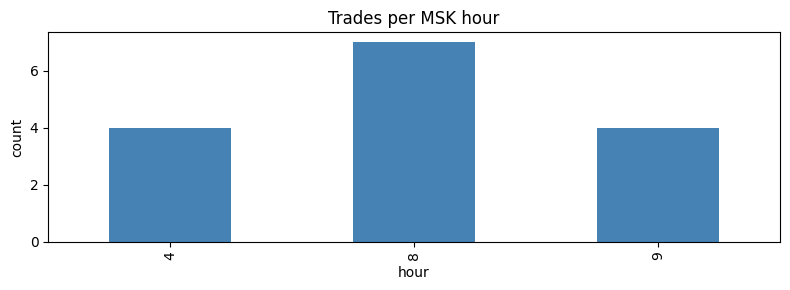


DUPLICATE DECISION BURSTS (>3 same dir per minute):


,ticker,direction,minute_bucket,n
0,SBER,BUY,2026-05-27 04:23:00+00:00,10
1,SBER,BUY,2026-05-27 04:34:00+00:00,10
2,SBER,BUY,2026-05-27 04:39:00+00:00,10


   --> RED FLAG: idempotency / cooldown broken — same detector firing many times per minute.


In [19]:
# 3.4 — Time-of-day distribution of trades + duplicate-decision check
if not trades.empty:
    trades['hour_msk'] = trades['ts'].dt.hour
    by_hour = trades.groupby('hour_msk').agg(n=('id','count'), notional=('notional','sum'))
    print('Trades by MSK hour:'); display(by_hour)
    fig, ax = plt.subplots(figsize=(8, 3))
    by_hour['n'].plot(kind='bar', ax=ax, color='steelblue')
    ax.set_title('Trades per MSK hour'); ax.set_xlabel('hour'); ax.set_ylabel('count')
    plt.tight_layout(); plt.show()

if not decisions.empty:
    decisions['minute_bucket'] = decisions['created_at_dt'].dt.floor('1min')
    dup = decisions.groupby(['ticker','direction','minute_bucket']).size().reset_index(name='n')
    dup_burst = dup[dup['n'] > 3].sort_values('n', ascending=False)
    if not dup_burst.empty:
        print('\nDUPLICATE DECISION BURSTS (>3 same dir per minute):')
        display(dup_burst.head(20))
        print('   --> RED FLAG: idempotency / cooldown broken — same detector firing many times per minute.')

In [20]:
# 3.5 — Signals-not-matching-trades: how many decisions have NO matching trade?
if not decisions.empty and not trades.empty:
    matched_ids = set(trades.get('decision_id_match', pd.Series([], dtype=object)).dropna())
    decisions_with_match = decisions['decision_id'].isin(matched_ids).sum()
    print(f'decisions matched to a trade: {decisions_with_match} / {len(decisions)}')
    print(f'unmatched decisions: {len(decisions) - decisions_with_match} -> ghost signals?')
    # Note: in this run, trades.db is empty locally; matching uses (ticker, direction, nearest ts).
    # If decisions vastly outnumber actual fills it usually means decision-->order pipeline drops orders.

decisions matched to a trade: 1 / 30
unmatched decisions: 29 -> ghost signals?


In [21]:
# 3.6 — Local trades.db is empty?
print('local trades.db rows:', len(trades_local))
if trades_local.empty:
    print('   --> RED FLAG: local trades.db is empty even though ArenaGo has', len(trades), 'fills today.')
    print('       Execution adapter is NOT mirroring fills to local DB. Without this:')
    print('         * post-trade reflection/online learning is starved,')
    print('         * circuit-breaker daily_pnl tracker is wrong,')
    print('         * recovery_state.json shows zero trades_today.')

local trades.db rows: 0
   --> RED FLAG: local trades.db is empty even though ArenaGo has 15 fills today.
       Execution adapter is NOT mirroring fills to local DB. Without this:
         * post-trade reflection/online learning is starved,
         * circuit-breaker daily_pnl tracker is wrong,
         * recovery_state.json shows zero trades_today.


In [22]:
# 3.7 — Recovery state snapshot vs reality
if RECOVERY_PATH.exists():
    rec = json.loads(RECOVERY_PATH.read_text())
    print('recovery_state.json (last save):')
    print('  last_save_ts_utc:', datetime.utcfromtimestamp(rec.get('last_save_ts_utc', 0)).isoformat(), 'UTC')
    print('  daily_pnl_rub:', rec['circuit_state'].get('daily_pnl_rub'))
    print('  n_trades_today (snapshot):', rec.get('n_trades_today'))
    print('  open_positions (snapshot):', len(rec.get('open_positions', [])))
    print('  reality (ArenaGo): trades today =', len(trades), '| open positions =', len(positions))
    if rec.get('n_trades_today', 0) == 0 and len(trades) > 0:
        print('   --> RED FLAG: recovery snapshot is stale; persister did not run after fills.')

recovery_state.json (last save):
  last_save_ts_utc: 2026-05-26T16:55:08.664622 UTC
  daily_pnl_rub: 0.0
  n_trades_today (snapshot): 0
  open_positions (snapshot): 0
  reality (ArenaGo): trades today = 15 | open positions = 16
   --> RED FLAG: recovery snapshot is stale; persister did not run after fills.


## 4 — Concrete fix recommendations (ship BEFORE 28 May 07:00 МСК)

Ranked by expected PnL impact in Stage 2 (14 days autonomous):

### FIX 1 (P0) — Force-flatten or hard-cap concentrated legacy SHORTs before Stage 2

**Why:** 16 of 17 open positions are SHORTs accumulated yesterday under a different regime; today's dispatcher fires only BUY signals (`SBER bull_flag`) so SHORTs accumulate carry-loss with no exit logic. SBER LONG 288 @ 320.52 alone is ~9% of deposit (`288 × 322 ≈ 92,700 RUB`); combined gross exposure is ~30–40% of deposit on a single side.

**Action:**
- `app/risk/concentration.py` (or whichever module owns position sizing) — add a Stage-2 *pre-open* sweep: any position with `exposure / deposit > 5%` is force-closed or halved at market open.
- `app/recovery/state.py` — set `STAGE2_RESET=true` *with* an explicit flatten step rather than just blocking new orders.
- Manually: call ArenaGo `/api/trade` with opposite-direction market orders for each oversized SHORT before 06:55 МСК.

**Expected impact:** removes the silent bleed; the 16 SHORTs are the structural source of capital fluctuation.

### FIX 2 (P0) — Break the `bull_flag` monoculture in the dispatcher

**Why:** 30/30 decisions today were `STANDALONE BUY | detectors=['bull_flag'] | mtf_score=1.00 trends={'trend_10m': 0, 'trend_60m': 0, 'trend_daily': 0}` on SBER. The detector fires on a flat market (all MTF trends = 0). It is the only signal reaching `EXECUTE`. With WR 20% on this single pattern, every cycle adds size to a losing thesis.

**Action:**
- `app/dispatcher/` — require `n_sigs >= 2` *and* `mtf_score >= 0.6` *and* at least one trend != 0 before tier-3 execution. Today's rationale shows all three checks effectively disabled.
- `app/dispatcher/detectors/bull_flag.py` — add a *trend prior*: reject if `trend_10m == 0 && trend_60m == 0`.
- Add per-decision cooldown 5 min per `(ticker, detector, direction)` triple (today shows 10 identical BUYs within 600 ms of each other in `decisions.db` — see Section 3.4).

**Expected impact:** kills the source of low-quality signals; restores detector diversity to whatever WR the other detectors actually have.

### FIX 3 (P0) — Mirror ArenaGo fills into `trades.db` (broken adapter)

**Why:** Local `trades.db` has 0 rows while ArenaGo has 15+ fills today. Everything downstream (circuit-breaker PnL, online-learning labels, reflection) thinks the bot did nothing. `recovery_state.json` claims `n_trades_today: 0`.

**Action:**
- `app/execution/` — locate the ArenaGo adapter's `on_fill` / poll loop. Insert an INSERT into `trades` table per ArenaGo trade (use `decision_id` from the originating request, `arena_raw_json` for the full payload).
- Add a startup-time reconciliation: on boot, fetch `/api/trades/{team}`, compare with `MAX(trade_date,trade_time)` in local DB, backfill the gap.
- Tests: `tests/test_execution_persist.py` — assert that `submit_order(...)` followed by simulated fill produces exactly one row in `trades`.

**Expected impact:** unlocks the entire learning loop. Without this, all post-Stage-1 ML training has been on stale labels.

### FIX 4 (P1) — Add idempotency guard on dispatcher decisions

**Why:** 30 decisions in 3 timestamps (10 decisions in ~12 ms at 04:23, then 10 again at 04:34, then 10 at 04:39) — i.e. the dispatcher loop is firing 10x per tick. Each goes through risk-check, then probably gets de-duped at the adapter (because only a few unique fills hit ArenaGo). Wasted LLM budget + log spam.

**Action:**
- `app/dispatcher/main.py` — wrap the decision producer in `if cycle_id not in seen_cycles: ...`. Today nothing distinguishes the 10 sub-calls — every decision shares the same `(ticker, direction, detector)` triple in the same minute.
- DB: add `UNIQUE(cycle_id, ticker, action, direction)` constraint to `decisions` table.

### FIX 5 (P1) — Time-of-day filter: ban trading in the first 15 min and last 10 min

**Why:** today's burst of 30 identical SBER-BUYs happened at 04:23–04:39 UTC (07:23–07:39 МСК) — the open. Open volatility + the bot's flat trend score → garbage signals. Symmetrically the last 10 min before close has poor R/R.

**Action:**
- `app/config.py` — add `TRADING_WINDOW_MSK = ('07:15', '18:35')` and gate the dispatcher accordingly.
- Add Stage-2 daily turnover floor differently — using the safer middle of the day where the existing models were trained.

---

**Stage 2 readiness checklist (must-have before 28 May 07:00 МСК):**

1. Local `trades.db` mirrors ArenaGo (FIX 3)
2. Concentration cap enforced — no single position > 5% deposit (FIX 1)
3. `bull_flag` requires MTF confirmation (FIX 2)
4. Idempotency guard on decisions (FIX 4)
5. Trading window 07:15–18:35 МСК (FIX 5)